## Data Visualization - CA2
## Matthew Riddell - D00245674
## Data Preparation and EDA

### Dataset source:

https://www.kaggle.com/datasets/mexwell/dublinbikes-dcc-dataset



### This code will also be uploaded to my github repo here:

https://github.com/Matthew-Riddell/Data-Visualization-CA2

#### Import Packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import glob

#### grabbing all files in the data folder

In [2]:
# https://www.w3schools.com/python/ref_module_glob.asp
file_path = "C:/Users/Matty/Documents/College Notes & Assignments/Year 5/Data Visualisation and Insight/CAs/CA2/Data-Visualization-CA2/data/*.csv"
files = glob.glob(file_path)

#### list for all files

In [3]:
df_list = []

#### read each file and add them to the list and then add them to a new dataframe 

In [4]:
for file in files:
    temp_df = pd.read_csv(file)
    df_list.append(temp_df)

data = pd.concat(df_list, ignore_index=True)

#### Size of the dataframe

In [5]:
data.shape

(1950289, 11)

#### Display first 5 rows

In [6]:
print("First 5 rows of the dataset:")
print(data.head())

First 5 rows of the dataset:
   STATION ID                 TIME         LAST UPDATED                NAME  \
0           2  2022-01-01 00:00:04  2021-12-31 23:57:39  BLESSINGTON STREET   
1           3  2022-01-01 00:00:04  2021-12-31 23:49:57       BOLTON STREET   
2           4  2022-01-01 00:00:04  2021-12-31 23:58:39        GREEK STREET   
3           5  2022-01-01 00:00:04  2021-12-31 23:51:48    CHARLEMONT PLACE   
4           6  2022-01-01 00:00:04  2021-12-31 23:59:13  CHRISTCHURCH PLACE   

   BIKE_STANDS  AVAILABLE_BIKE_STANDS  AVAILABLE_BIKES STATUS  \
0           20                     10               10   OPEN   
1           20                     19                1   OPEN   
2           20                      9               11   OPEN   
3           40                     17               23   OPEN   
4           20                     13                7   OPEN   

              ADDRESS  LATITUDE  LONGITUDE  
0  Blessington Street   53.3568   -6.26814  
1       Bolton 

#### Display column names

In [7]:
print("Original column names:")
print(data.columns)

Original column names:
Index(['STATION ID', 'TIME', 'LAST UPDATED', 'NAME', 'BIKE_STANDS',
       'AVAILABLE_BIKE_STANDS', 'AVAILABLE_BIKES', 'STATUS', 'ADDRESS',
       'LATITUDE', 'LONGITUDE'],
      dtype='object')


#### Check basic information about the dataset

In [8]:
print("Information about the dataset:")
print(data.info())

Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1950289 entries, 0 to 1950288
Data columns (total 11 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   STATION ID             int64  
 1   TIME                   object 
 2   LAST UPDATED           object 
 3   NAME                   object 
 4   BIKE_STANDS            int64  
 5   AVAILABLE_BIKE_STANDS  int64  
 6   AVAILABLE_BIKES        int64  
 7   STATUS                 object 
 8   ADDRESS                object 
 9   LATITUDE               float64
 10  LONGITUDE              float64
dtypes: float64(2), int64(4), object(5)
memory usage: 163.7+ MB
None


#### Convert time field into a datetime object

In [9]:
data["TIME"] = pd.to_datetime(data["TIME"])

### Creating new features

#### Create Time features

In [10]:
data["HOUR"] = data["TIME"].dt.hour
data["DAY"] = data["TIME"].dt.day
data["MONTH"] = data["TIME"].dt.month
data["WEEKDAY"] = data["TIME"].dt.day_name()
data["DATE"] = data["TIME"].dt.date

#### Bike usage metric

In [11]:
data["USAGE"] = data["BIKE_STANDS"] - data["AVAILABLE_BIKES"]

#### Weekend Metric

In [12]:
data["IS_WEEKEND"] = data["WEEKDAY"].isin(["Saturday", "Sunday"])

### Data Cleaning

#### Check for missing values in the dataset

In [13]:
print("Number of missing values in each column:")
print(data.isna().sum())

Number of missing values in each column:
STATION ID               0
TIME                     0
LAST UPDATED             0
NAME                     0
BIKE_STANDS              0
AVAILABLE_BIKE_STANDS    0
AVAILABLE_BIKES          0
STATUS                   0
ADDRESS                  0
LATITUDE                 0
LONGITUDE                0
HOUR                     0
DAY                      0
MONTH                    0
WEEKDAY                  0
DATE                     0
USAGE                    0
IS_WEEKEND               0
dtype: int64


#### Show total missing values across the dataset

In [14]:
total_missing = data.isna().sum().sum()
print("Total missing values in the dataset:", total_missing)

Total missing values in the dataset: 0


#### List containing possible missing values in the columns 

In [15]:
nonsense_values = ["?", "error", "missing", "Missing", "NaN", "nan", "N/A", "n/a", "--", " "]

#### Checking the nonsense_values list across the dataset

In [16]:
print("Checking for nonsense values:")
for col in data.columns:
    count = data[col].isin(nonsense_values).sum() 
    if count > 0:
        print(col, "has", count, "nonsense values")

Checking for nonsense values:


#### Replace all nonsense values with NaN

In [17]:
data = data.replace(nonsense_values, np.nan)

#### Check again for missing values after replacement

In [18]:
print("Number of missing values after cleaning nonsense values:")
print(data.isna().sum())

Number of missing values after cleaning nonsense values:
STATION ID               0
TIME                     0
LAST UPDATED             0
NAME                     0
BIKE_STANDS              0
AVAILABLE_BIKE_STANDS    0
AVAILABLE_BIKES          0
STATUS                   0
ADDRESS                  0
LATITUDE                 0
LONGITUDE                0
HOUR                     0
DAY                      0
MONTH                    0
WEEKDAY                  0
DATE                     0
USAGE                    0
IS_WEEKEND               0
dtype: int64


#### List of columns with numerical data

In [19]:
numeric_columns = ['BIKE_STANDS', 'AVAILABLE_BIKE_STANDS', 'AVAILABLE_BIKES', 'USAGE']

#### Dropping rows with missing values

In [20]:
for col in numeric_columns:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

print("Shape before dropping rows with missing values:", data.shape)
data = data.dropna()
print("Shape after dropping rows with missing values:", data.shape)

print("Missing values after filling numeric columns with mean:")
print(data.isna().sum())

Shape before dropping rows with missing values: (1950289, 18)
Shape after dropping rows with missing values: (1950289, 18)
Missing values after filling numeric columns with mean:
STATION ID               0
TIME                     0
LAST UPDATED             0
NAME                     0
BIKE_STANDS              0
AVAILABLE_BIKE_STANDS    0
AVAILABLE_BIKES          0
STATUS                   0
ADDRESS                  0
LATITUDE                 0
LONGITUDE                0
HOUR                     0
DAY                      0
MONTH                    0
WEEKDAY                  0
DATE                     0
USAGE                    0
IS_WEEKEND               0
dtype: int64


#### Outlier Detection

In [21]:
print("Detecting outliers using IQR method:\n")

for col in numeric_columns:
    if col in data.columns:
        Q1 = data[col].quantile(0.25) # https://www.w3schools.com/Python/pandas/ref_df_quantile.asp
        Q3 = data[col].quantile(0.75) # https://www.w3schools.com/Python/pandas/ref_df_quantile.asp
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        
        outliers = data[(data[col] < lower_limit) | (data[col] > upper_limit)]
        print(col, "has", outliers.shape[0], "outliers")

Detecting outliers using IQR method:

BIKE_STANDS has 958 outliers
AVAILABLE_BIKE_STANDS has 0 outliers
AVAILABLE_BIKES has 11037 outliers
USAGE has 0 outliers


#### Final Preview of cleaned dataset

In [22]:
data.head(5)

,STATION ID,TIME,LAST UPDATED,NAME,BIKE_STANDS,AVAILABLE_BIKE_STANDS,AVAILABLE_BIKES,STATUS,ADDRESS,LATITUDE,LONGITUDE,HOUR,DAY,MONTH,WEEKDAY,DATE,USAGE,IS_WEEKEND
0,2,2022-01-01 00:00:04,2021-12-31 23:57:39,BLESSINGTON STREET,20,10,10,OPEN,Blessington Street,53.3568,-6.26814,0,1,1,Saturday,2022-01-01,10,True
1,3,2022-01-01 00:00:04,2021-12-31 23:49:57,BOLTON STREET,20,19,1,OPEN,Bolton Street,53.3512,-6.26986,0,1,1,Saturday,2022-01-01,19,True
2,4,2022-01-01 00:00:04,2021-12-31 23:58:39,GREEK STREET,20,9,11,OPEN,Greek Street,53.3469,-6.27298,0,1,1,Saturday,2022-01-01,9,True
3,5,2022-01-01 00:00:04,2021-12-31 23:51:48,CHARLEMONT PLACE,40,17,23,OPEN,Charlemont Street,53.3307,-6.26018,0,1,1,Saturday,2022-01-01,17,True
4,6,2022-01-01 00:00:04,2021-12-31 23:59:13,CHRISTCHURCH PLACE,20,13,7,OPEN,Christchurch Place,53.3434,-6.27012,0,1,1,Saturday,2022-01-01,13,True


### Creating Separate Aggregated Datasets 

Creating separate datasets due to the sheer size of the unified dataset (3 million rows)

Also to better model the data around the questions I wish to answer / visualize in Shiny

#### Hourly Data of Bike Availablity

In [23]:
data_hourly = data.groupby(
    ["HOUR"]
)["AVAILABLE_BIKES"].mean().reset_index()

In [37]:
data_hourly.head()

,HOUR,AVAILABLE_BIKES
0,0,12.627926
1,1,12.769600
2,2,12.791801
3,3,12.797242
4,4,12.798844


#### Hourly Data of Station Activity

In [24]:
data_station_hour = data.groupby(
    ["STATION ID", "NAME", "HOUR"]
)["AVAILABLE_BIKES"].mean().reset_index()

In [36]:
data_station_hour.head()

,STATION ID,NAME,HOUR,AVAILABLE_BIKES
0,1,CLARENDON ROW,0,9.621457
1,1,CLARENDON ROW,1,9.443548
2,1,CLARENDON ROW,2,9.380567
3,1,CLARENDON ROW,3,9.384615
4,1,CLARENDON ROW,4,9.403651


#### Daily Bike Availability

In [25]:
data_daily = data.groupby(
    ["DATE"]
)["AVAILABLE_BIKES"].mean().reset_index()

In [35]:
data_daily.head()

,DATE,AVAILABLE_BIKES
0,2022-01-01,12.689752
1,2022-01-02,12.648461
2,2022-01-03,12.659159
3,2022-01-04,12.445571
4,2022-01-05,12.480758


#### Bike Station Data

In [26]:
data_station = data.groupby(
    ["STATION ID", "NAME", "LATITUDE", "LONGITUDE"],
    as_index=False
).agg({
    "AVAILABLE_BIKES": "mean",
    "BIKE_STANDS": "max" 
})

In [34]:
data_station.head()

,STATION ID,NAME,LATITUDE,LONGITUDE,AVAILABLE_BIKES,BIKE_STANDS
0,1,CLARENDON ROW,53.3409,-6.26250,13.204032,31
1,2,BLESSINGTON STREET,53.3568,-6.26814,7.604003,20
2,3,BOLTON STREET,53.3512,-6.26986,10.563629,20
3,4,GREEK STREET,53.3469,-6.27298,10.600505,20
4,5,CHARLEMONT PLACE,53.3307,-6.26018,19.295005,40


#### Bike Availability during the week

In [27]:
data_week = data.groupby(
    ["HOUR", "IS_WEEKEND"]
)["AVAILABLE_BIKES"].mean().reset_index()

In [33]:
data_week.head()

,HOUR,IS_WEEKEND,AVAILABLE_BIKES
0,0,False,12.655275
1,0,True,12.560462
2,1,False,12.773699
3,1,True,12.759493
4,2,False,12.786299


### EDA of aggregated datasets

#### Daily available bikes

In [28]:
fig = px.line(
    data_daily,
    x="DATE",
    y="AVAILABLE_BIKES",
    title="Daily Available Bikes"
)

fig.show()

#### Hourly pattern

In [30]:
fig = px.line(
    data_hourly,
    x="HOUR",
    y="AVAILABLE_BIKES",
    title="Hourly Pattern"
)

fig.show()

#### Average bikes per station

In [31]:
fig = px.bar(
    data_station,
    x="NAME",
    y="AVAILABLE_BIKES",
    title="Average Bikes per Station"
)

fig.update_layout(xaxis_tickangle=-45)

fig.show()

#### Weekday vs Weekend 

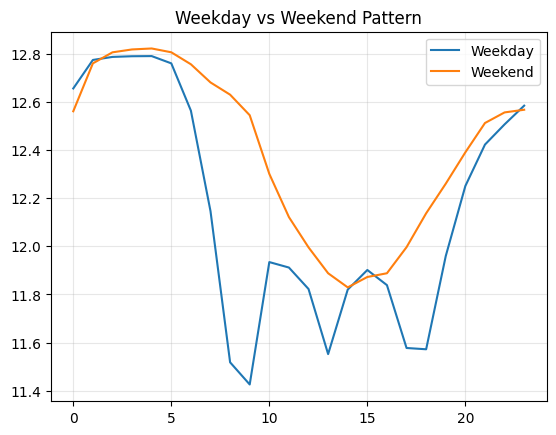

In [32]:
fig, ax = plt.subplots()

for label, g in data_week.groupby("IS_WEEKEND"):
    name = "Weekend" if label == 1 else "Weekday"
    ax.plot(g["HOUR"], g["AVAILABLE_BIKES"], label=name)

ax.set_title("Weekday vs Weekend Pattern")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

### Dataset Export

In [29]:
### data.to_csv("dublinbikes_2022_combined.csv", index=False)

data_hourly.to_csv("hourly.csv", index=False)
data_station_hour.to_csv("station_hour.csv", index=False)
data_daily.to_csv("daily.csv", index=False)
data_station.to_csv("station_summary.csv", index=False)
data_week.to_csv("week.csv", index=False)